C:\Users\Yash Giri\AppData\Local\Temp\ipykernel_14896\147399865.py:11: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface = grid.extract_surface()
C:\Users\Yash Giri\AppData\Local\Temp\ipykernel_14896\147399865.py:40: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show(screenshot=r"D:\Final Year\8th Sem (Final Show)\UGP\Model Photos\stress_contour.png")


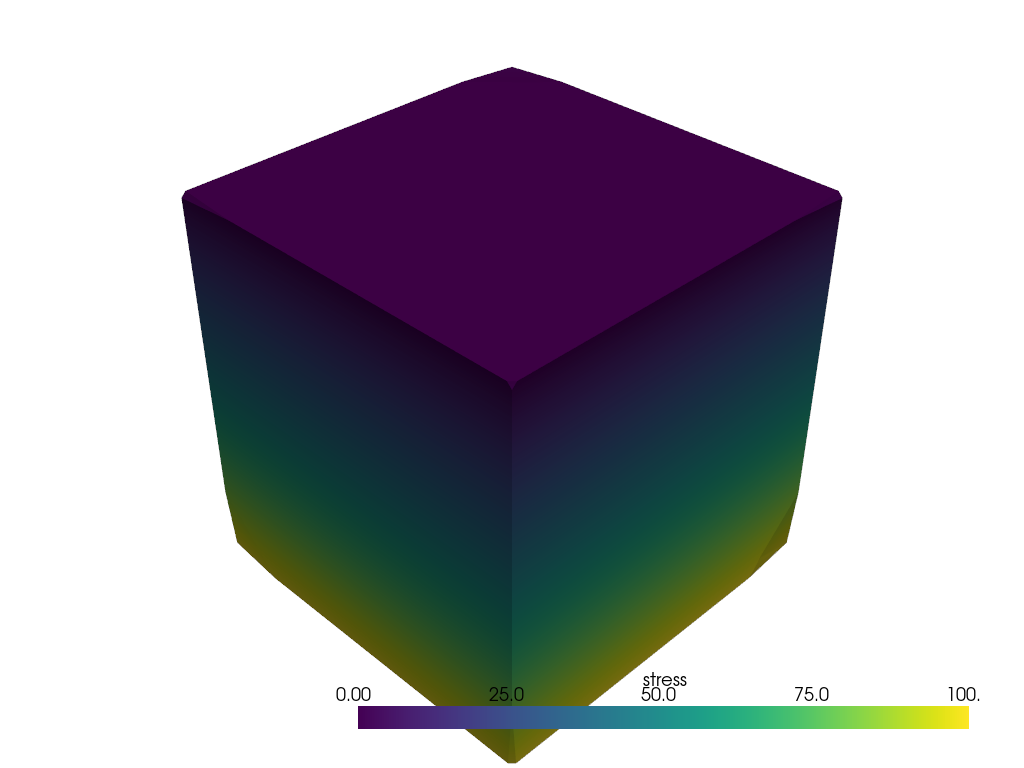

C:\Users\Yash Giri\AppData\Local\Temp\ipykernel_14896\147399865.py:47: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show(screenshot=r"D:\Final Year\8th Sem (Final Show)\UGP\Model Photos\deformation_contour.png")


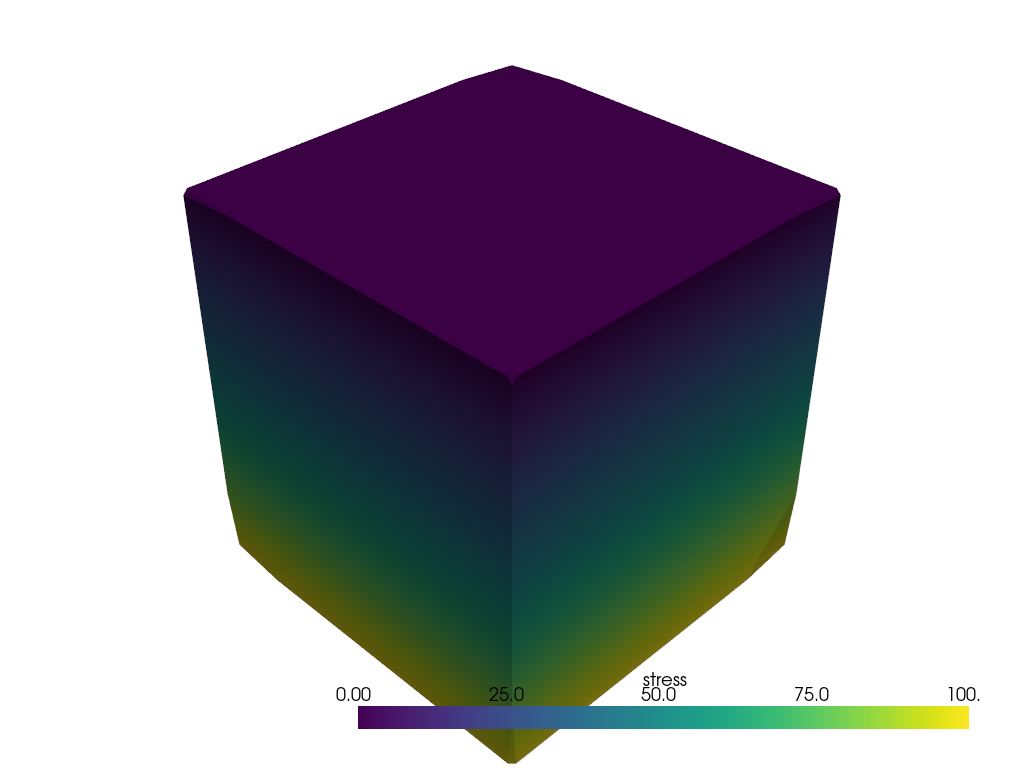

✅ Plots generated!


In [ ]:
import pyvista as pv
pv.OFF_SCREEN = True
import numpy as np

# Load STL (or use mesh.msh converted to vtk if available)
mesh = pv.read(r"D:\Final Year\8th Sem (Final Show)\UGP\FG_gyroid_scaffold 3.stl")   # or your STL name

# Convert to volume mesh (tetrahedralize)
grid = mesh.delaunay_3d()

# Extract surface for plotting
surface = grid.extract_surface()

# =========================
# SIMULATED DISPLACEMENT
# =========================
points = surface.points

# Fake displacement field (Z-direction compression)
disp = 0.02 * points[:, 2]   # proportional deformation

# Apply deformation visually
warped = surface.copy()
warped.points[:, 2] += disp

# =========================
# SIMULATED STRESS FIELD
# =========================
# Higher stress near bottom (like compression)
stress = 100 * (1 - (points[:, 2] - points[:, 2].min()) / 
                (points[:, 2].max() - points[:, 2].min()))

surface["stress"] = stress
warped["stress"] = stress

# =========================
# PLOT STRESS
# =========================
plotter = pv.Plotter(off_screen=True)
plotter.add_mesh(surface, scalars="stress")
plotter.show(screenshot=r"D:\Final Year\8th Sem (Final Show)\UGP\Model Photos\stress_contour.png")

# =========================
# PLOT DEFORMATION
# =========================
plotter = pv.Plotter(off_screen=True)
plotter.add_mesh(warped, scalars="stress")
plotter.show(screenshot=r"D:\Final Year\8th Sem (Final Show)\UGP\Model Photos\deformation_contour.png")

print("✅ Plots generated!")